### 第 06 章 策略梯度基础


#### 本章概述

本章将介绍策略梯度（Policy Gradient）方法，这是强化学习中与基于价值（Value-based）方法并列的另一大类核心算法。策略梯度直接对策略进行参数化，并通过梯度上升的方法最大化期望回报。

**学习目标**：
- 理解策略参数化和目标函数。
- 掌握策略梯度定理的严谨推导过程。
- 实现经典的 REINFORCE 算法及其带基线（Baseline）的版本。
- 理解策略梯度中的高方差问题及基线为何能降低方差。

**前置知识**：
- 马尔可夫决策过程（MDP）和轨迹（Trajectory）的概念。
- 深度学习中的自动求导和优化器。


##### 6.1 策略梯度定理


**理论部分**

不同于 DQN 等通过学习动作价值函数 $Q(s, a)$ 来隐式推导策略（例如 $\epsilon$-greedy），**策略梯度（Policy Gradient, PG）** 方法直接使用一个带有参数 $\theta$ 的模型（如神经网络）来近似策略：
$$ \pi_\theta(a|s) = \mathbb{P}(A_t = a | S_t = s; \theta) $$

这种方法有几个明显的优势：
1. 能够学习**随机策略（Stochastic Policy）**，这在部分可观测环境或存在博弈对抗的环境中非常必要。
2. 容易处理**连续动作空间**。
3. 策略的变化是平滑的，而基于价值的方法在 Q 值发生微小改变时，贪心动作可能会发生突变，导致训练不稳定。

**目标函数**
为了优化参数 $\theta$，我们需要定义一个目标函数 $J(\theta)$，用来衡量当前策略的好坏。对于回合制（Episodic）任务，目标函数通常定义为初始状态的期望回报：
$$ J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} [R(\tau)] $$
其中，$\tau = (s_0, a_0, r_1, s_1, a_1, r_2, \dots, s_T)$ 表示一条完整的交互轨迹（Trajectory），而 $R(\tau) = \sum_{t=0}^{T-1} \gamma^t r_{t+1}$ 是该轨迹的总折扣回报。轨迹 $\tau$ 出现的概率分布取决于环境的动态转移概率 $p(s_{t+1}|s_t, a_t)$ 以及我们的策略 $\pi_\theta(a_t|s_t)$：
$$ p_\theta(\tau) = p(s_0) \prod_{t=0}^{T-1} \pi_\theta(a_t|s_t) p(s_{t+1}|s_t, a_t) $$

**策略梯度定理推导**
我们的目标是最大化 $J(\theta)$，因此需要计算它关于 $\theta$ 的梯度 $\nabla_\theta J(\theta)$。
$$ \boxed{\nabla_\theta J(\theta) = \nabla_\theta \mathbb{E}_{\tau \sim \pi_\theta} [R(\tau)] = \nabla_\theta \sum_\tau p_\theta(\tau) R(\tau) = \sum_\tau \nabla_\theta p_\theta(\tau) R(\tau)} $$

这里引入一个非常重要的数学技巧（对数微分技巧, Log-derivative trick），因为 $\nabla_\theta \log p_\theta(\tau) = \frac{\nabla_\theta p_\theta(\tau)}{p_\theta(\tau)}$，我们可以改写上述公式：
$$ \nabla_\theta J(\theta) = \sum_\tau p_\theta(\tau) \frac{\nabla_\theta p_\theta(\tau)}{p_\theta(\tau)} R(\tau) = \sum_\tau p_\theta(\tau) \nabla_\theta \log p_\theta(\tau) R(\tau) = \mathbb{E}_{\tau \sim \pi_\theta} \left[ \nabla_\theta \log p_\theta(\tau) R(\tau) \right] $$

接下来展开轨迹概率的对数 $\log p_\theta(\tau)$：
$$ \log p_\theta(\tau) = \log p(s_0) + \sum_{t=0}^{T-1} \log \pi_\theta(a_t|s_t) + \sum_{t=0}^{T-1} \log p(s_{t+1}|s_t, a_t) $$

当我们对 $\theta$ 求梯度时，环境初始状态分布 $p(s_0)$ 和环境转移概率 $p(s_{t+1}|s_t, a_t)$ 均与 $\theta$ 无关，它们的梯度为 0！这就得到了著名的**策略梯度定理（Policy Gradient Theorem）** 的基本形式：
$$ \boxed{\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} \left[ \left( \sum_{t=0}^{T-1} \nabla_\theta \log \pi_\theta(a_t|s_t) \right) R(\tau) \right] }$$

这说明，我们**不需要知道环境的模型**（转移概率），只需要知道当前策略 $\pi_\theta$ 选出动作的对数概率的梯度，并用轨迹的总回报 $R(\tau)$ 去加权它。如果 $R(\tau)$ 为正且很大，就会增加整条轨迹中所有动作出现的概率。

**关键要点**：
- 策略梯度通过直接对策略参数化来优化期望回报。
- 对数微分技巧（Log-derivative trick）将概率梯度转化为了期望形式，使得我们可以通过蒙特卡洛采样来估计梯度。
- 策略梯度的计算不需要环境动态模型，属于无模型（Model-free）方法。


##### 6.2 REINFORCE 算法


**理论部分**

上节推导出的策略梯度公式中，权重是整条轨迹的总回报 $R(\tau)$。但在时间步 $t$ 采取的动作 $a_t$ 只会影响时间步 $t$ 之后的奖励，而不会影响 $t$ 之前的奖励。因此，我们可以将梯度公式进一步改进，也就是将 $R(\tau)$ 替换成时间步 $t$ 之后的累积回报：
$$ \nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} \left[ \sum_{t=0}^{T-1} \nabla_\theta \log \pi_\theta(a_t|s_t) G_t \right] $$
其中 $G_t = \sum_{k=t}^{T-1} \gamma^{k-t} r_{k+1}$ 是从时间步 $t$ 开始的**折扣累积回报（Discounted Return）**。

基于这个改进后的公式的蒙特卡洛算法，就是经典的 **REINFORCE 算法**。

**REINFORCE 算法流程**：
1. 初始化策略网络参数 $\theta$。
2. 对每次训练回合（Episode）：
   1. 使用当前策略 $\pi_\theta$ 在环境中交互，生成一条完整轨迹 $\tau = (s_0, a_0, r_1, s_1, \dots, s_{T})$。
   2. 对于 $t = 0, 1, \dots, T-1$，计算实际的累积回报 $G_t$。
   3. 根据公式 $\theta \leftarrow \theta + \alpha \nabla_\theta \log \pi_\theta(a_t|s_t) G_t$ 更新参数。通常在深度学习中，我们将其转换为构建一个“伪损失函数”并通过反向传播来最小化它：$Loss = - \frac{1}{T} \sum_{t=0}^{T-1} G_t \log \pi_\theta(a_t|s_t)$。
   
**关键要点**：
- REINFORCE 是策略梯度的蒙特卡洛（Monte Carlo）实现，需要运行完整的 Episode 才能进行更新。
- 使用 $G_t$ 代替 $R(\tau)$ 作为动作 $a_t$ 的评估标准（因果关系：现在的动作只影响未来），这能在一定程度上降低梯度的方差。


In [2]:
import gym
import math
import random
import numpy as np
# 兼容性处理
np.bool8 = np.bool_
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# ===============================
# 定义策略网络 (Policy Network)
# ===============================
# 与 DQN 输出 Q 值不同，策略网络输出的是动作的概率分布
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, action_dim)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        # 最后一层使用 Softmax，将网络输出转换为各动作的概率分布
        action_probs = F.softmax(self.fc2(x), dim=-1)
        return action_probs

# ===============================
# 定义 REINFORCE 智能体
# ===============================
class REINFORCEAgent:
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.policy_net = PolicyNetwork(state_dim, action_dim).to(self.device)
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.gamma = gamma
        
        # 用于存储一条轨迹的交互数据
        self.saved_log_probs = []
        self.saved_rewards = []
        
    def select_action(self, state):
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        # 前向传播得到概率分布
        probs = self.policy_net(state_tensor)
        
        # 使用 torch.distributions.Categorical 根据概率分布进行采样
        from torch.distributions import Categorical
        m = Categorical(probs)
        action = m.sample()
        
        # 保存该动作对应的 log probability，留到更新时计算梯度
        self.saved_log_probs.append(m.log_prob(action))
        return action.item()
    
    def store_reward(self, reward):
        self.saved_rewards.append(reward)
        
    def update(self):
        # 1. 计算每个时间步的折扣累积回报 G_t
        G_t = []
        R = 0
        # 逆序计算以提高效率
        for r in self.saved_rewards[::-1]:
            R = r + self.gamma * R
            G_t.insert(0, R)
            
        G_t = torch.tensor(G_t).to(self.device)
        
        # （可选）回报归一化：有助于稳定训练，减小方差
        G_t = (G_t - G_t.mean()) / (G_t.std() + 1e-9)
        
        # 2. 构建策略梯度的伪损失函数：Loss = - sum(log_prob * G_t)
        policy_loss = []
        for log_prob, g in zip(self.saved_log_probs, G_t):
            policy_loss.append(-log_prob * g)
        
        policy_loss = torch.cat(policy_loss).sum()
        
        # 3. 梯度反向传播和参数更新
        self.optimizer.zero_grad()
        policy_loss.backward()
        self.optimizer.step()
        
        # 4. 清空这一回合的存储，准备下一次
        self.saved_log_probs.append(None) # just in case, but let's re-init
        self.saved_log_probs = []
        self.saved_rewards = []


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


##### 6.3 基线函数（Baseline）


**理论部分**

REINFORCE 算法中，我们用 $G_t$ 来“加权” $\nabla_\theta \log \pi_\theta(a_t|s_t)$。如果所有的 $G_t$ 都是很大的正数，那么不管好动作还是坏动作，它们的概率都会被增加，只是增加的幅度不同。经过多次采样后可能收敛，但方差极大，训练非常不稳定。

为此，我们在权重项中引入一个与动作 $a_t$ 无关的**基线函数（Baseline）** $b(s_t)$：
$$ \nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} \left[ \sum_{t=0}^{T-1} \nabla_\theta \log \pi_\theta(a_t|s_t) (G_t - b(s_t)) \right] $$

为什么可以引入 $b(s_t)$ 呢？因为在期望下，基线函数的梯度贡献严格为 0（证明如下）：
$$ \mathbb{E}_{a_t \sim \pi} [\nabla_\theta \log \pi_\theta(a_t|s_t) b(s_t)] = \sum_{a_t} \pi_\theta(a_t|s_t) \frac{\nabla_\theta \pi_\theta(a_t|s_t)}{\pi_\theta(a_t|s_t)} b(s_t) = b(s_t) \nabla_\theta \sum_{a_t} \pi_\theta(a_t|s_t) = b(s_t) \nabla_\theta (1) = 0 $$

引入基线后，$G_t - b(s_t)$ 表示动作 $a_t$ 比“平均水平（基线）”好多少，这也就是**优势（Advantage）**的概念。

最常见的做法是使用状态价值函数 $V^\pi(s_t)$ 作为基线。因为 $V^\pi(s_t) = \mathbb{E}_\pi[G_t | s_t]$，刚好代表状态 $s_t$ 的平均期望回报。我们需要额外训练一个参数为 $\omega$ 的**价值网络（Value Network）** $V_\omega(s)$ 来拟合实际采样的 $G_t$。这就是 **REINFORCE with Baseline** 算法。

**关键要点**：
- 引入基线函数 $b(s_t)$ 不改变梯度的期望值（无偏估计）。
- $G_t - b(s_t)$ 使得回报有正有负，增加了好动作的概率，降低了差动作的概率，大幅加速了学习。
- 状态价值函数 $V(s)$ 是最理想的基线选择。


--- Training standard REINFORCE ---
Episode 100/600, Reward: 45.35
Episode 200/600, Reward: 105.00
Episode 300/600, Reward: 160.70
Episode 400/600, Reward: 200.10
Episode 500/600, Reward: 242.60
Episode 600/600, Reward: 284.75

--- Training REINFORCE with Baseline ---
Episode 100/600, Reward: 24.65
Episode 200/600, Reward: 51.45
Episode 300/600, Reward: 184.70
Episode 400/600, Reward: 344.65
Episode 500/600, Reward: 437.80
Episode 600/600, Reward: 390.05


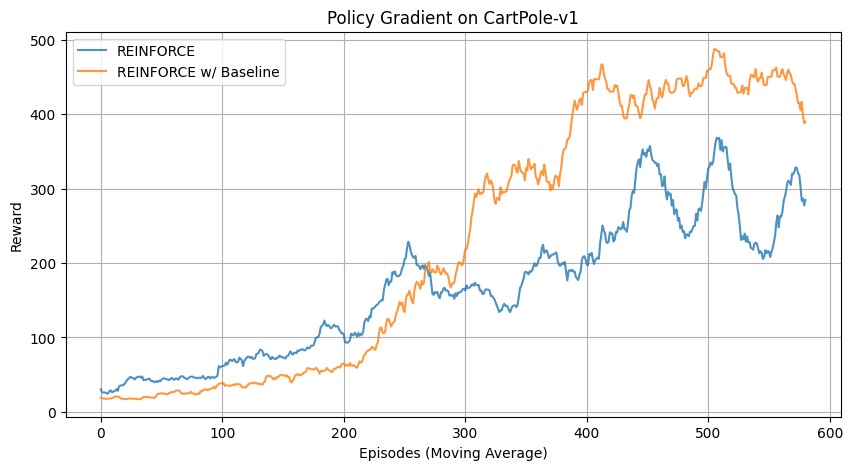

In [3]:
# ===============================
# 定义价值网络 (Value Network) 作为基线
# ===============================
class ValueNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim=128):
        super(ValueNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        # 价值网络输出一个标量 V(s)
        self.fc2 = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        state_value = self.fc2(x)
        return state_value

# ===============================
# 定义 REINFORCE with Baseline 智能体
# ===============================
class REINFORCEBaselineAgent:
    def __init__(self, state_dim, action_dim, lr_policy=1e-3, lr_value=1e-3, gamma=0.99):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        # 策略网络 (Actor)
        self.policy_net = PolicyNetwork(state_dim, action_dim).to(self.device)
        self.policy_optimizer = optim.Adam(self.policy_net.parameters(), lr=lr_policy)
        
        # 价值网络 (Critic Baseline)
        self.value_net = ValueNetwork(state_dim).to(self.device)
        self.value_optimizer = optim.Adam(self.value_net.parameters(), lr=lr_value)
        
        self.gamma = gamma
        self.saved_log_probs = []
        self.saved_states = []
        self.saved_rewards = []
        
    def select_action(self, state):
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        self.saved_states.append(state_tensor)
        
        probs = self.policy_net(state_tensor)
        from torch.distributions import Categorical
        m = Categorical(probs)
        action = m.sample()
        
        self.saved_log_probs.append(m.log_prob(action))
        return action.item()
    
    def store_reward(self, reward):
        self.saved_rewards.append(reward)
        
    def update(self):
        # 1. 计算每个时间步的折扣累积回报 G_t
        G_t = []
        R = 0
        for r in self.saved_rewards[::-1]:
            R = r + self.gamma * R
            G_t.insert(0, R)
        G_t = torch.tensor(G_t).to(self.device)
        
        # 2. 将状态输入价值网络计算基线 V(s)
        states_tensor = torch.cat(self.saved_states)
        V_s = self.value_net(states_tensor).squeeze(1)
        
        # 3. 计算优势 Advantage: A = G_t - V(s)
        # 对 V_s 进行 detach() 以避免在策略更新时梯度传导到价值网络
        advantages = G_t - V_s.detach()
        
        # 4. 计算策略网络的损失
        policy_loss = []
        for log_prob, adv in zip(self.saved_log_probs, advantages):
            policy_loss.append(-log_prob * adv)
        policy_loss = torch.cat(policy_loss).sum()
        
        # 5. 计算价值网络的损失 (用 MSE 去拟合 G_t)
        value_loss = F.mse_loss(V_s, G_t)
        
        # 6. 更新策略网络
        self.policy_optimizer.zero_grad()
        policy_loss.backward()
        self.policy_optimizer.step()
        
        # 7. 更新价值网络
        self.value_optimizer.zero_grad()
        value_loss.backward()
        self.value_optimizer.step()
        
        # 清空数据
        self.saved_log_probs = []
        self.saved_states = []
        self.saved_rewards = []

# ===============================
# 训练循环与性能对比展示
# ===============================
def train_agent(agent, env_name="CartPole-v1", max_episodes=500):
    env = gym.make(env_name)
    rewards = []
    
    for episode in range(max_episodes):
        state = env.reset()
        if isinstance(state, tuple):
            state = state[0]
        
        episode_reward = 0
        done = False
        truncated = False
        
        while not (done or truncated):
            action = agent.select_action(state)
            step_result = env.step(action)
            
            if len(step_result) == 5:
                next_state, reward, done, truncated, _ = step_result
            else:
                next_state, reward, done, _ = step_result
                truncated = False
                
            agent.store_reward(reward)
            state = next_state
            episode_reward += reward
            
        # 回合结束后更新参数 (蒙特卡洛更新)
        agent.update()
        rewards.append(episode_reward)
        
        if (episode + 1) % 100 == 0:
            print(f"Episode {episode+1}/{max_episodes}, Reward: {np.mean(rewards[-20:]):.2f}")
            
    env.close()
    return rewards

if __name__ == "__main__":
    state_dim = 4
    action_dim = 2
    max_episodes = 600

    print("--- Training standard REINFORCE ---")
    reinforce_agent = REINFORCEAgent(state_dim, action_dim)
    reinforce_rewards = train_agent(reinforce_agent, max_episodes=max_episodes)

    print("\n--- Training REINFORCE with Baseline ---")
    baseline_agent = REINFORCEBaselineAgent(state_dim, action_dim)
    baseline_rewards = train_agent(baseline_agent, max_episodes=max_episodes)

    # 绘制滑动平均曲线对比
    def moving_average(a, n=20):
        ret = np.cumsum(a, dtype=float)
        ret[n:] = ret[n:] - ret[:-n]
        return ret[n - 1:] / n

    plt.figure(figsize=(10, 5))
    plt.plot(moving_average(reinforce_rewards), label="REINFORCE", alpha=0.8)
    plt.plot(moving_average(baseline_rewards), label="REINFORCE w/ Baseline", alpha=0.8)
    plt.title("Policy Gradient on CartPole-v1")
    plt.xlabel("Episodes (Moving Average)")
    plt.ylabel("Reward")
    plt.legend()
    plt.grid(True)
    plt.show()


##### 6.4 策略梯度的方差问题


**理论部分**

方差过高是策略梯度方法的核心痛点之一。高方差意味着梯度的估计非常不稳定，导致参数更新时常发生剧烈震荡，难以收敛。

**为什么方差会高？**
1. **轨迹的随机性**：蒙特卡洛采样每次得到的轨迹长度、经历的状态、奖励可能差别巨大。
2. **回报累计（Cumulative Rewards）**：$G_t$ 是从时间步 $t$ 到终点的一连串随机奖励之和（$r_{t+1} + \gamma r_{t+2} + \dots$），累加了多个时间步的噪声。
3. **连乘效应**：轨迹概率分布 $p_\theta(\tau)$ 涉及到多个时间步策略分布概率的连乘，任何一步的波动都会被放大。

**降低方差的常用技术**：
1. **因果推理（Causality）**：使用 $G_t$ 替代 $R(\tau)$，即只考虑动作发生之后的奖励，这在 6.2 节中已讨论。
2. **引入基线（Baseline）**：使用 $G_t - b(s_t)$ 使得权重零均值化，这是降低方差的最重要技术之一，在 6.3 节中进行了实现。从代码对比中可以看出，引入基线后算法的学习曲线往往更加平滑稳定。
3. **Actor-Critic 架构**：下一章将要介绍的架构，用时间差分（TD）估计的目标替代蒙特卡洛采样的 $G_t$。TD 估计引入了偏差（Bias），但大幅降低了方差（Bias-Variance Tradeoff）。
4. **批处理（Mini-batch）**：一次采样多条轨迹，计算平均梯度再更新，利用大数定律降低方差。

**关键要点**：
- 策略梯度由于依赖蒙特卡洛采样和序列累加奖励，本质上具有很高的方差。
- 减小方差但保持无偏（或引入可控偏差）是后续各类现代强化学习算法（如 Actor-Critic, PPO 等）演进的主要驱动力。


#### 本章小结

本章我们学习了基于梯度的策略优化方法：
1. 策略梯度定理通过对数微分技巧将梯度转换为期望形式，从而可以使用蒙特卡洛方法采样估计。
2. REINFORCE 算法是策略梯度的基本实现，它通过完整的轨迹采样计算 $G_t$ 来更新策略。
3. 为了解决方差过大的问题，我们引入了基线函数（Baseline），形成了 REINFORCE with Baseline 算法，它有效加快了学习过程。

**关键概念回顾**：
- 策略参数化（Policy Parameterization）
- 对数微分技巧（Log-derivative trick）
- REINFORCE
- 基线（Baseline）与优势（Advantage）
- 方差与偏差的权衡（Bias-Variance Tradeoff）

**下一章预告**：
在下一章，我们将介绍 Actor-Critic（演员-评论家）方法。它将本章学习的策略梯度（Actor）与前一章学习的价值函数（Critic）结合起来，利用时序差分（TD）误差代替蒙特卡洛回报 $G_t$，从而进一步提升学习效率并实现在线（Online）更新。
